# Predicting the category of a clothing item using an ML model with PyTorch

A convolutional neural network will be used to classify the images of clothing items into distinct categories.
A convolution is essentially the weighted sum of the pixel values of an image as the window slides across the image.
The advantage of this approach is that the size of the model is independant of the size of the image. Data augmentation is especially useful when it comes to training the model, through image rotations, changes in lighting and scale.

In [13]:
%pip install numpy
%pip install tensorflow
%pip install matplotlib

In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

## Dataset loading

The dataset used is FashionMNIST, which contain 60.000 training and 10.000 testing 28x28 images split into 10 categories:

0) T-shirt / Top
1) Trouser
2) Pullover
3) Dress
4) Coat
5) Sandal
6) Shirt
7) Sneaker
8) Bag
9) Ankle boot

In [15]:
dataset = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = dataset.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [16]:
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


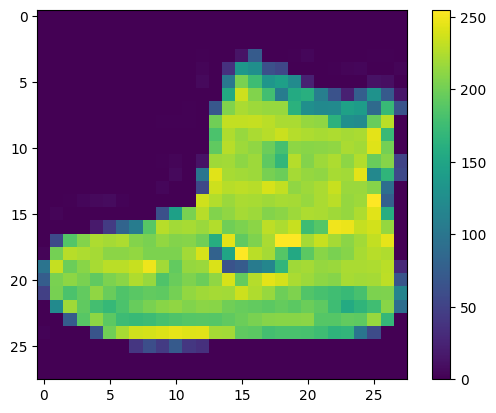

In [17]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

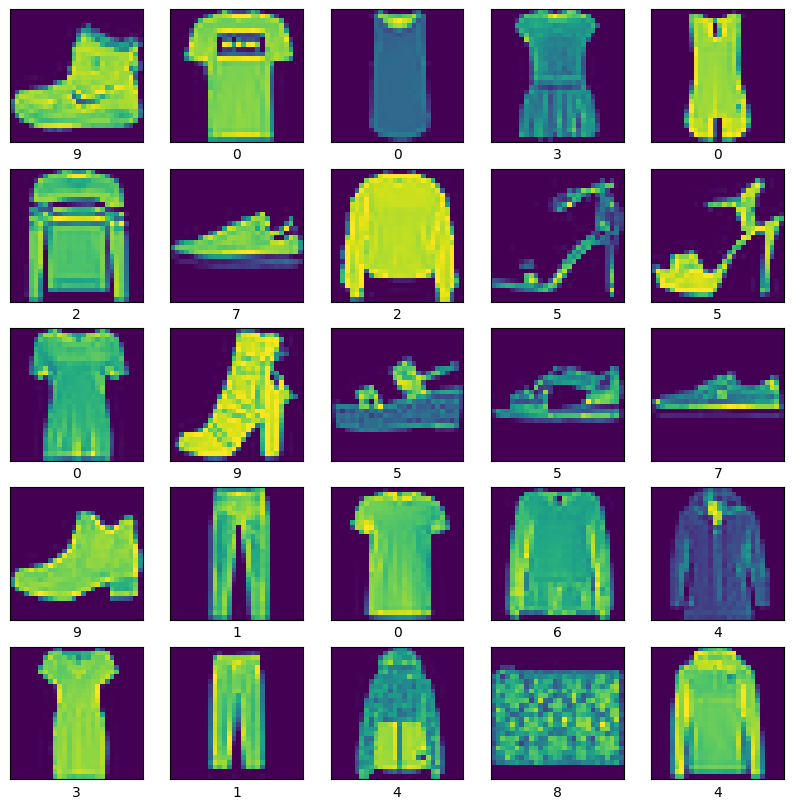

In [18]:
train_images = train_images / 255
test_images = test_images / 255

plt.figure(figsize = (10, 10))
for i in range(25):
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i])
  plt.xlabel(train_labels[i])
plt.show()

## Standard Neural Network


In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (28, 28)),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])

model.compile(
    optimizer = 'adam',     # Determines how the model weights are updated
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True), # Measures the accuracy of the model in training
    metrics = ['accuracy']    # Used to monitor the training and testing steps
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Training

In [20]:
model.fit(train_images, train_labels, epochs = 10)


Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8250 - loss: 0.4978
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8642 - loss: 0.3768
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8778 - loss: 0.3367
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8849 - loss: 0.3130
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8903 - loss: 0.2958
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8961 - loss: 0.2806
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9005 - loss: 0.2672
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9053 - loss: 0.2545
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9079 - loss: 0.2480
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9108 - loss: 0.2384


### Testing

In [21]:
model.evaluate(test_images, test_labels, verbose = 2)

313/313 - 2s - 7ms/step - accuracy: 0.8828 - loss: 0.3326


[0.33264732360839844, 0.8827999830245972]

## Convolutional neural network

Given the above results when trying to perform image classification with traditional neural networks, a convolutional neural network is used instead. Traditionally these consist of 3 layers:
1) Convolutional layers: apply a sliding window function to a matrix of pixels representing an image, called the kernel or filter and used to recognize specific patterns within the image. Multiple kernels of the same size are used in a convolution layer each extracting a different feature. These layers are followed by ReLU activations to avoid overfitting
2) Pooling layers: used to reduce the dimensions of the extracted convoluted matrix by extracting only the most important features, to reduce the memory needed by the NN
3) Fully connected layers: located in the end of the network with size equal to that of the flattened matrix produced by the last pooling layer. Usually a softmax function is applied in the end

In [22]:
%pip install torchvision
%pip install torchmetrics
%pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import torchvision
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchmetrics
from itertools import product
from sklearn.metrics import precision_score, recall_score

In [36]:
# Transformation to normalize the data and perform data augmentation
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,)),
                                transforms.RandomHorizontalFlip(),
                                transforms.RandomRotation(15),
                                transforms.ColorJitter(brightness=0.2, contrast=0.2)]
                              )

# Load the dataset
train_set = datasets.FashionMNIST(root = './data', train = True, download = True, transform = transform)
test_set = datasets.FashionMNIST(root = './data', train = False, download = True, transform = transform)



In [53]:
# Define the CNN architecture (two convolutional layers, one pooling and one fully connected layer)
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    # 28x28x3 -> 28x28x32
    self.conv1 = nn.Conv2d(1, 32, 3, stride = 1, padding = 1)
    self.conv2 = nn.Conv2d(32, 64, 3, stride = 1, padding = 1)
    self.conv3 = nn.Conv2d(64, 128, 3, stride = 1, padding = 1)
    self.pool = nn.MaxPool2d(2, 2)
    self.fc1 = nn.Linear(128 * 7 * 7, 128)
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
    x = F.relu(self.conv1(x))
    x = self.pool(x)
    x = F.relu(self.conv2(x))
    x = self.pool(x)
    x = F.relu(self.conv3(x))
    # x = self.pool(x)
    x = x.view(x.size(0), -1)
    x = self.fc1(x)
    x = self.fc2(x)
    x = F.softmax(x, dim = 1)
    return x

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
loss_fn = nn.CrossEntropyLoss()

# Tuned hyperparameters
learning_rates = [0.001, 0.0001, 0.01, 0.00001]
batch_sizes = [64, 128, 256, 512]
epochs = [10, 20, 30]

# Grid search
best_parameters = {}
best_accuracy = 0

# Split the dataset into training and validation set
train_size = int(0.8 * len(train_set))
eval_size = len(train_set) - train_size
train_ds, eval_ds = random_split(train_set, [train_size, eval_size])
for lr, batch_size, num_epochs in product(learning_rates, batch_sizes, epochs):
  print(f"Parameters used : learning rate {lr}, batch size {batch_size}, epochs {num_epochs}")

  # Input in dataloaders to handle shuffling and batching
  train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
  eval_loader = DataLoader(eval_ds, batch_size = batch_size, shuffle = True)

  # Training
  model = CNN().to(device)
  optimizer = optim.Adam(model.parameters(), lr = lr)
  model.train()
  for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}")
    for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
      data = data.to(device)
      targets = targets.to(device)
      preds = model(data)
      loss = loss_fn(preds, targets)
      optimizer.zero_grad()   # Reset the gradients
      loss.backward()         # Backpropagation
      optimizer.step()        # Update the weights

  # Evaluation
  total = 0
  correct = 0
  model.eval()
  with torch.no_grad():
    for batch_index, (data, targets) in enumerate(tqdm(eval_loader)):
      data = data.to(device)
      targets = targets.to(device)
      preds = model(data)
      predicted = preds.argmax(dim=1)
      total += targets.size(0)
      correct += (predicted == targets).sum().item()
  accuracy = 100 * correct / total
  print(f"Accuracy: {accuracy}")
  print("===============================================================")
  if accuracy > best_accuracy:
    best_accuracy = accuracy
    best_parameters = {'learning_rate': lr, 'batch_size': batch_size, 'epochs': num_epochs}
print(best_parameters)

Parameters used : learning rate 0.001, batch size 64, epochs 10
Epoch 1


100%|██████████| 750/750 [00:54<00:00, 13.83it/s]


Epoch 2


100%|██████████| 750/750 [01:01<00:00, 12.23it/s]


Epoch 3


...

100%|██████████| 375/375 [00:55<00:00,  6.71it/s]


Epoch 3


100%|██████████| 375/375 [00:52<00:00,  7.19it/s]


Epoch 4


  8%|▊         | 30/375 [00:04<00:57,  5.97it/s]

### Testing the final model

In [ ]:
test_loader = DataLoader(test_set, batch_size = batch_size, shuffle = True)
optimizer = optim.Adam(model.parameters(), lr = best_parameters['learning_rate'])

accuracy = 0
total = 0
correct = 0
model.eval()
with torch.no_grad():
  for batch_index, (data, targets) in enumerate(test_loader):
      data = data.to(device)
      targets = targets.to(device)
      preds = model(data)
      total += targets.size(0)
      correct += (preds == targets).sum().item()
  accuracy = 100 * correct / total
  precision = precision_score(targets, preds, average = 'macro')
  recall = recall_score(targets, preds, average = 'macro')
  print(f"Accuracy: {accuracy}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")

## Deploying the model in Google Drive


In [ ]:
%pip install keras
from keras.saving import save_model
from google.colab import drive
import os
drive.mount('/content/drive')
os.mkdir('/content/drive/models')
save_model(model, '/content/drive/models/classifier.keras')